# Encounter publication validation

## tl;dr

This notebook is the lightweight, reader-facing audit trail for the
heterogeneous encounter publication artifacts.  It verifies, without
rerunning the expensive solvers, that:

- the stated finite-state CTMC fold has dimensionless first/second
  residuals below $10^{-10}$, nonzero third derivative and parameter
  transversality, and held-out separation/prominence slopes close to
  $1/2$ and $3/2$;
- an exact finite $4\times4$ Green fixture has a shared dark mode, a
  coupled negative killed pole, and two nonzero channel residues
  that cancel in the total reaction flux;
- a finite reversible spectral diagnostic satisfies the necessary
  three-/five-sign-change bounds in the production bimodal and
  trimodal models, while exact counterexamples block sufficiency
  and killing-rank mode bounds;
- a fixed-budget modality gradient agrees across Fr\'echet,
  Duhamel, held-out finite-difference, permutation, random-direction,
  and production-fold chain-rule checks;
- the four-grid base artifact is the M2D-C separated-boundary
  branch, with $9\times5$ retained as conditional on its strict tail
  gate; its $11\times7$ curve is reused in the control artifact and
  is not an independent replication. The remaining M2D-C controls
  separate resolved morphology from strict-root count and include a
  bimodal uniform-reactivity counterexample;
- the matched-budget finite-radius 2D family has fold residuals
  verified to the declared numerical tolerances,
  nonzero third derivative and parameter transversality on three grids,
  with separation/prominence exponents close to $1/2$ and $3/2$;
  its M2D-F endpoint audit gives homogeneous resolved-unimodal and
  patterned resolved-bimodal calls on all five grids. The fold
  coordinate spans about 0.262 and is explicitly **not** called
  grid-converged; three folds also persist under a
  product-control-volume budget measure, but their locations move
  substantially;
- midpoint and diffusivity-weighted catalyst coordinates define
  different finite-grid sinks and densities even though both give a
  coarse shoulder and two finer bimodal labels in this audit;
- one fixed obstacle-free reflecting-rectangle Doi model has three
  strict modes, five alternating detected stationary roots, and
  ordered near/middle/far channel dominance on four grids; the
  classifier resolves all three on the three finer grids and calls
  the coarsest a shoulder;
- a free-space narrow-patch GIG construction resolves 2, 3, and 4 modes
  in all 12 dimension/channel-count screens;
- the separate M2D-E patterned-versus-per-lattice-state-sum-matched
  control has homogeneous resolved-unimodal calls on all five grids,
  four finer patterned bimodal calls, and one coarse strict
  amplification/shoulder case;
- the finest saved 2D logarithmic-capacity slope is 0.9848 of theory;
- the smallest-four 3D inverse-effective-radius slope is 0.9989 of
  theory.

These are finite-state, finite-grid, and free-space screening results.
The bounded trimodal result is a finite-grid mechanism certificate.
These artifacts do **not** by themselves prove a continuum
patterned-reactivity modality fold, a bounded-domain continuum
trimodality theorem, or a continuum phase boundary.

## Context & Methods

The intended reader is a referee or collaborator who wants to trace
the paper-facing conclusions to saved numerical artifacts.  Every
input is under
`research/reports/encounter_heterogeneous_catalytic/artifacts/data/`.
The notebook locates the repository by walking upward from its fixed
execution directory and refuses to continue if any required artifact
is absent.

### Key Assumptions

1. Artifact generators and their manifests are audited elsewhere; this
   notebook validates the saved values and independently recomputes
   only inexpensive regressions.
2. Two distinct finite-state fold families are audited below: the stated
   finite $L=31$ CTMC fold and a matched-budget finite-radius 2D fold
   on $9\times5$, $11\times7$, and $13\times9$ grids.  Neither is a
   continuum theorem.
3. Negative-half-plane Green evaluation is used only for finite
   rational matrices outside the free spectrum. It is not a
   continuum meromorphic-continuation claim or a physical Laplace
   transform at negative $s$.
4. The four-grid bounded 2D three-clock calculation fixes one physical
   parameter set and audits sign-changing roots on a declared finite
   interval. Three grids are resolved trimodal and the coarsest is a
   shoulder. It claims neither an exhaustive positive-time root count
   nor a continuum theorem or phase-boundary calculation.
5. All bounded 2D headline calculations declare the arithmetic
   midpoint catalyst coordinate.  The weighted coordinate is audited
   only as a distinct sensitivity comparator and as the special
   free-space GIG decoupling coordinate; equivalence is not assumed.
6. The 2D and 3D capacity calculations use translation-invariant
   relative-coordinate quotients.  They calibrate target scaling but
   do not establish a centre-patterned multidimensional fold.
7. The separate M2D-E matched homogeneous ablation equates the
   per-lattice discrete sum of statewise killing rates; it does not equate every
   trajectory-level hazard.
8. The finite-radius 2D fold location fails its declared cross-grid
   tolerance. Only the M2D-F finite-grid mechanism, local normal form,
   and its all-five homogeneous-resolved-unimodal/
   patterned-resolved-bimodal endpoint
   audit are promoted; M2D-E is the separate four-contrast-plus-one-
   shoulder experiment in item 7.
9. The multidimensional 2/3/4-mode design is a free-space narrow-patch
   GIG screening construction.  Physical realization of its designed
   mixture weights is not claimed by that screen.

## Data

### 1. Locate the repository and load bounded artifacts

In [1]:
import hashlib
import importlib.metadata as package_metadata
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd
from IPython.display import display

%matplotlib inline

def locate_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        data_dir = candidate / "research/reports/encounter_heterogeneous_catalytic/artifacts/data"
        if data_dir.is_dir() and (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError(f"Could not locate valley-k-small from {start}")

REPO_ROOT = locate_repo_root(Path.cwd())
REPORT_ROOT = REPO_ROOT / "research/reports/encounter_heterogeneous_catalytic"
DATA_DIR = REPORT_ROOT / "artifacts/data"

expected_python = Path(os.environ["ENCOUNTER_PUBLICATION_EXPECTED_PYTHON"]).absolute()
actual_python = Path(sys.executable).absolute()
assert os.path.samefile(actual_python, expected_python), (
    f"Notebook kernel drifted from the pipeline interpreter: "
    f"kernel={actual_python} expected={expected_python}"
)
direct_packages = (
    "ipykernel", "jupyter-client", "matplotlib", "nbclient",
    "nbformat", "numpy", "pandas", "scipy",
)
kernel_runtime = {
    "executable": str(actual_python),
    "python": sys.version.split()[0],
    "packages": {
        name: package_metadata.version(name) for name in direct_packages
    },
}

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 10,
})

print(f"Repository root: {REPO_ROOT}")
print(f"Python: {sys.version.split()[0]}; nbformat: {nbformat.__version__}")
print("KERNEL_RUNTIME_JSON=" + json.dumps(kernel_runtime, sort_keys=True))

Repository root: /Users/ae23069/Library/CloudStorage/OneDrive-UniversityofBristol/Desktop/valley-k-small
Python: 3.12.13; nbformat: 5.10.4
KERNEL_RUNTIME_JSON={"executable": "/Users/ae23069/.local-build/valley-k-small/.venv/bin/python3", "packages": {"ipykernel": "7.3.0", "jupyter-client": "8.9.1", "matplotlib": "3.11.0", "nbclient": "0.11.0", "nbformat": "5.10.4", "numpy": "2.5.1", "pandas": "3.0.3", "scipy": "1.18.0"}, "python": "3.12.13"}


In [2]:
artifact_names = {
    "fold_summary": "gig_fold_summary.json",
    "fold_continuation": "gig_fold_continuation.csv",
    "fold_series": "gig_fold_series.npz",
    "green_spectrum": "finite_matrix_green_spectral_audit.json",
    "modality_design": "modality_susceptibility_summary.json",
    "spectral_modality": "spectral_modality_summary.json",
    "spectral_coefficients": "spectral_modality_coefficients.csv",
    "fold_2d": "finite_radius_2d_fold_metrics.json",
    "base_2d": "finite_radius_2d_metrics.json",
    "base_2d_series": "finite_radius_2d_series.npz",
    "controls_2d": "finite_radius_2d_control_metrics.json",
    "controls_2d_series": "finite_radius_2d_mechanism_series.npz",
    "interior_2d": "finite_radius_2d_interior_metrics.json",
    "domain_2d": "finite_radius_2d_domain_scaling.json",
    "centre_coordinate_2d": "finite_radius_2d_centre_coordinate.json",
    "trimodal_2d": "finite_radius_2d_trimodal_metrics.json",
    "trimodal_2d_series": "finite_radius_2d_trimodal_series.npz",
    "multid_gig": "multid_gig_design_summary.json",
    "matched_json": "finite_radius_2d_matched_control.json",
    "matched_table": "finite_radius_2d_matched_control.csv",
    "matched_series": "finite_radius_2d_matched_control_series.npz",
    "capacity_2d_rows": "finite_radius_2d_capacity_rows.csv",
    "capacity_2d_fits": "finite_radius_2d_capacity_fits.csv",
    "capacity_2d_summary": "finite_radius_2d_capacity_metrics.json",
    "capacity_3d_rows": "finite_radius_3d_radius_convergence.csv",
    "capacity_3d_grid": "finite_radius_3d_grid_convergence.csv",
    "capacity_3d_summary": "finite_radius_3d_capacity_metrics.json",
}
artifact_paths = {key: DATA_DIR / name for key, name in artifact_names.items()}
missing = [str(path.relative_to(REPO_ROOT)) for path in artifact_paths.values() if not path.is_file()]
assert not missing, f"Missing required artifacts: {missing}"

fold_summary = json.loads(artifact_paths["fold_summary"].read_text())
green_spectrum = json.loads(artifact_paths["green_spectrum"].read_text())
modality_design = json.loads(artifact_paths["modality_design"].read_text())
spectral_modality = json.loads(artifact_paths["spectral_modality"].read_text())
spectral_coefficients = pd.read_csv(artifact_paths["spectral_coefficients"])
fold_continuation = pd.read_csv(artifact_paths["fold_continuation"])
with np.load(artifact_paths["fold_series"], allow_pickle=False) as archive:
    fold_series = {key: archive[key].copy() for key in archive.files}

fold_2d = json.loads(artifact_paths["fold_2d"].read_text())
base_2d = json.loads(artifact_paths["base_2d"].read_text())
with np.load(artifact_paths["base_2d_series"], allow_pickle=False) as archive:
    base_2d_series = {key: archive[key].copy() for key in archive.files}
controls_2d = json.loads(artifact_paths["controls_2d"].read_text())
with np.load(artifact_paths["controls_2d_series"], allow_pickle=False) as archive:
    controls_2d_series = {key: archive[key].copy() for key in archive.files}
interior_2d = json.loads(artifact_paths["interior_2d"].read_text())
domain_2d = json.loads(artifact_paths["domain_2d"].read_text())
centre_coordinate_2d = json.loads(
    artifact_paths["centre_coordinate_2d"].read_text()
)
trimodal_2d = json.loads(artifact_paths["trimodal_2d"].read_text())
with np.load(artifact_paths["trimodal_2d_series"], allow_pickle=False) as archive:
    trimodal_2d_series = {key: archive[key].copy() for key in archive.files}
multid_gig = json.loads(artifact_paths["multid_gig"].read_text())

matched = pd.DataFrame(
    json.loads(artifact_paths["matched_json"].read_text())
)
with np.load(artifact_paths["matched_series"], allow_pickle=False) as archive:
    matched_series = {key: archive[key].copy() for key in archive.files}

capacity_2d_rows = pd.read_csv(artifact_paths["capacity_2d_rows"])
capacity_2d_fits = pd.read_csv(artifact_paths["capacity_2d_fits"])
capacity_2d_summary = json.loads(artifact_paths["capacity_2d_summary"].read_text())
capacity_3d_rows = pd.read_csv(artifact_paths["capacity_3d_rows"])
capacity_3d_grid = pd.read_csv(artifact_paths["capacity_3d_grid"])
capacity_3d_summary = json.loads(artifact_paths["capacity_3d_summary"].read_text())

source_inventory = pd.DataFrame([
    {
        "artifact": path.name,
        "bytes": path.stat().st_size,
        "sha256_16": hashlib.sha256(path.read_bytes()).hexdigest()[:16],
    }
    for path in artifact_paths.values()
])
display(source_inventory)
print(f"Loaded {len(source_inventory)} bounded artifacts; no solver was rerun.")

,artifact,bytes,sha256_16
0,gig_fold_summary.json,6637,47d04892bf297f77
1,gig_fold_continuation.csv,1989,8c9e72da5f39582c
2,gig_fold_series.npz,190226,5fa2b3cab997669e
3,finite_matrix_green_spectral_audit.json,5802,ca0f532bbe3ff471
4,modality_susceptibility_summary.json,3713,b97b79cd25c7b422
5,spectral_modality_summary.json,8372,1bc45cebe9b8b1da
6,spectral_modality_coefficients.csv,188604,fc1896e3ef04dba7
7,finite_radius_2d_fold_metrics.json,86235,a143ed1af928d649
8,finite_radius_2d_metrics.json,6838,f4651166e7b31cea
9,finite_radius_2d_series.npz,115271,3e3c82452c2d0299


Loaded 27 bounded artifacts; no solver was rerun.


## Results

### 2. Validate the finite CTMC fold and held-out normal form

In [3]:
physical_fold = fold_summary["physical_CTMC_fold"]
normal_form = fold_summary["normal_form"]

held_out = fold_continuation.loc[
    (fold_continuation["side"] == "two-peak-side")
    & (fold_continuation["delta_theta"] <= normal_form["held_out_fit_max_delta"])
].copy()
separation_slope, separation_intercept = np.polyfit(
    np.log(held_out["delta_theta"]),
    np.log(held_out["critical_point_separation"]),
    1,
)
prominence_slope, prominence_intercept = np.polyfit(
    np.log(held_out["delta_theta"]),
    np.log(held_out["local_prominence"]),
    1,
)

fold_checks = {
    "first_residual_below_1e-10": abs(physical_fold["dimensionless_first_residual"]) < 1e-10,
    "second_residual_below_1e-10": abs(physical_fold["dimensionless_second_residual"]) < 1e-10,
    "third_derivative_nondegenerate": abs(physical_fold["dimensionless_third_derivative"]) > 1.0,
    "parameter_transversality_nondegenerate": abs(physical_fold["dimensionless_transversality"]) > 0.01,
    "mass_closure_below_1e-12": physical_fold["mass_closure_error"] < 1e-12,
    "held_out_separation_near_half": abs(separation_slope - 0.5) < 0.02,
    "held_out_prominence_near_three_halves": abs(prominence_slope - 1.5) < 0.03,
    "one_and_two_peak_controls_present": (
        fold_summary["controls"]["one_peak_side_points"] >= 7
        and fold_summary["controls"]["two_peak_side_points"] >= 7
    ),
}
assert all(fold_checks.values()), fold_checks
assert np.isclose(separation_slope, normal_form["held_out_separation_loglog_slope"], atol=1e-12)
assert np.isclose(prominence_slope, normal_form["held_out_prominence_loglog_slope"], atol=1e-12)

fold_metrics = pd.DataFrame([
    ("dimensionless first residual", physical_fold["dimensionless_first_residual"], "< 1e-10"),
    ("dimensionless second residual", physical_fold["dimensionless_second_residual"], "< 1e-10"),
    ("dimensionless third derivative", physical_fold["dimensionless_third_derivative"], "nonzero"),
    ("dimensionless transversality", physical_fold["dimensionless_transversality"], "nonzero"),
    ("mass closure error", physical_fold["mass_closure_error"], "< 1e-12"),
    ("held-out separation slope", separation_slope, "0.5"),
    ("held-out prominence slope", prominence_slope, "1.5"),
    ("near splitting probability", physical_fold["near_splitting_probability"], "disclose"),
], columns=["metric", "observed", "criterion/reference"])
display(fold_metrics)
print("Finite CTMC fold checks: PASS")

,metric,observed,criterion/reference
0,dimensionless first residual,7.120828e-15,< 1e-10
1,dimensionless second residual,6.775053e-13,< 1e-10
2,dimensionless third derivative,6.994207e+01,nonzero
3,dimensionless transversality,-1.962021e-01,nonzero
4,mass closure error,3.996803e-15,< 1e-12
5,held-out separation slope,5.009544e-01,0.5
6,held-out prominence slope,1.508770e+00,1.5
7,near splitting probability,8.945768e-06,disclose


Finite CTMC fold checks: PASS


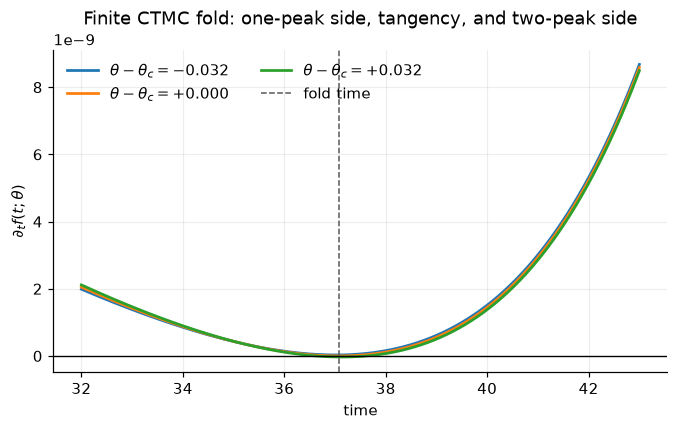

In [4]:
local_times = fold_series["local_times"]
offsets = fold_series["physical_theta_offsets"]
local_derivatives = fold_series["physical_local_first_derivatives"]

fig, ax = plt.subplots(figsize=(7.2, 3.8))
for offset, derivative in zip(offsets, local_derivatives):
    ax.plot(local_times, derivative, lw=1.8, label=fr"$\theta-\theta_c={offset:+.3f}$")
ax.axhline(0.0, color="black", lw=0.9)
ax.axvline(physical_fold["time"], color="0.35", ls="--", lw=1.0, label="fold time")
ax.set(xlabel="time", ylabel=r"$\partial_t f(t;\theta)$",
       title="Finite CTMC fold: one-peak side, tangency, and two-peak side")
ax.legend(frameon=False, ncol=2)
plt.show()

### 3. Validate the finite Green pole/dark-mode/residue fixture

In [5]:
dark = green_spectrum["dark_shared_mode"]
pole = green_spectrum["coupled_killed_pole"]
residues = green_spectrum["residue_cancellation"]
green_spectral_checks = {
    "finite_only_scope": (
        "finite 4x4" in green_spectrum["claim_scope"]
        and "no continuum" in green_spectrum["claim_scope"]
    ),
    "exact_dark_mode": (
        np.isclose(dark["eigenvalue"], -2.0)
        and dark["selector_coupling_inf_norm"] < 1e-14
        and dark["free_eigen_residual_inf_norm"] < 1e-14
        and dark["killed_eigen_residual_inf_norm"] < 1e-14
    ),
    "coupled_pole_outside_free_spectrum": (
        np.isclose(pole["eigenvalue"], -2.5)
        and np.isclose(pole["distance_to_free_spectrum"], 0.5)
        and pole["selector_coupling_l2_norm"] > 0.9
    ),
    "renewal_determinant_zero": (
        abs(pole["renewal_determinant"]) < 1e-13
        and pole["renewal_smallest_singular_value"] < 1e-14
        and pole["renewal_null_residual_inf_norm"] < 1e-14
    ),
    "nonzero_channel_residues_cancel_in_total": (
        np.allclose(residues["channel_residues"], [0.25, -0.25], atol=1e-14)
        and residues["minimum_absolute_channel_residue"] > 0.24
        and abs(residues["total_observable_residue"]) < 1e-14
    ),
    "determinant_lemma_both_half_planes": all(
        row["absolute_error"] < 1e-13
        for row in green_spectrum["determinant_lemma_checks"]
    ),
    "near_pole_residue_recovery": (
        pole["near_pole"]["green_accuracy_diagnostic"] < 1e-8
        and pole["near_pole"]["max_difference_from_eigenprojector_residue"] < 4e-6
    ),
    "zero_rate_inverse_free": (
        green_spectrum["zero_rate_inverse_free_check"]["reaction_rates"]
        == [0.0, 0.5]
        and green_spectrum["zero_rate_inverse_free_check"]["zero_channel_transform"]
        == {"real": 0.0, "imag": 0.0}
    ),
}
assert all(green_spectral_checks.values()), green_spectral_checks
continuum_green_meromorphic_continuation_claimed = False

green_spectral_table = pd.DataFrame([
    ("shared dark eigenvalue", dark["eigenvalue"], "U^T v = 0"),
    ("coupled killed pole", pole["eigenvalue"], "det(I+GK) = 0"),
    ("distance to free spectrum", pole["distance_to_free_spectrum"], "> 0"),
    ("channel residue 1", residues["channel_residues"][0], "nonzero"),
    ("channel residue 2", residues["channel_residues"][1], "nonzero"),
    ("total-flux residue", residues["total_observable_residue"], "zero"),
], columns=["quantity", "value", "certificate"])
display(green_spectral_table)
print("Finite Green spectral fixture: PASS — dark mode, coupled pole, residue cancellation.")
print("Continuum meromorphic continuation claimed: FALSE.")

,quantity,value,certificate
0,shared dark eigenvalue,-2.00,U^T v = 0
1,coupled killed pole,-2.50,det(I+GK) = 0
2,distance to free spectrum,0.50,> 0
3,channel residue 1,0.25,nonzero
4,channel residue 2,-0.25,nonzero
5,total-flux residue,0.00,zero


Finite Green spectral fixture: PASS — dark mode, coupled pole, residue cancellation.
Continuum meromorphic continuation claimed: FALSE.


The negative spectral parameters in this fixture belong to finite
rational matrix algebra.  The physical Laplace API remains on
$\operatorname{Re}s\geq0$, and the continuum Green operator is not
continued into the left half-plane by this calculation.

### 4. Validate the matched-budget finite-radius 2D fold mechanism

In [6]:
fold_2d_records = []
for row in fold_2d["grids"]:
    fold = row["fold"]
    scaling = row["scaling"]
    held_out = row["held_out"]
    fold_2d_records.append({
        "grid": f"{row['grid'][0]}x{row['grid'][1]}",
        "theta_c": fold["theta"],
        "time_c": fold["time"],
        "max_abs_fold_residual": max(abs(fold["f_t_residual"]), abs(fold["f_tt_residual"])),
        "max_dimensionless_fold_residual": fold["max_dimensionless_residual"],
        "f_ttt": fold["f_ttt"],
        "f_ttheta": fold["f_ttheta"],
        "Jacobian determinant": fold["jacobian_determinant"],
        "separation exponent": scaling["separation_exponent"],
        "prominence exponent": scaling["prominence_exponent"],
        "subcritical stationary points": len(held_out["subcritical"]["local_stationary_points"]),
        "supercritical stationary points": len(held_out["supercritical"]["local_stationary_points"]),
        "budget error": row["budget_invariance_error"],
    })
fold_2d_table = pd.DataFrame(fold_2d_records)

fold_2d_max_residual = float(fold_2d_table["max_abs_fold_residual"].max())
fold_2d_max_dimensionless_residual = float(
    fold_2d_table["max_dimensionless_fold_residual"].max()
)
fold_2d_nondegenerate = bool(
    (fold_2d_table["f_ttt"].abs() > 1e-7).all()
    and (fold_2d_table["f_ttheta"].abs() > 1e-6).all()
    and (fold_2d_table["Jacobian determinant"].abs() > 1e-12).all()
)
fold_2d_scaling_pass = bool(
    ((fold_2d_table["separation exponent"] - 0.5).abs() < 0.02).all()
    and ((fold_2d_table["prominence exponent"] - 1.5).abs() < 0.03).all()
)
fold_2d_side_controls_pass = bool(
    fold_2d_table["subcritical stationary points"].eq(0).all()
    and fold_2d_table["supercritical stationary points"].eq(2).all()
)
fold_2d_budget_pass = bool(fold_2d_table["budget error"].max() < 2e-12)

grid_comparison = fold_2d["grid_comparison"]
assert fold_2d_max_residual < 5e-14
assert fold_2d_max_dimensionless_residual < 1e-8
assert fold_2d_nondegenerate
assert fold_2d_scaling_pass
assert fold_2d_side_controls_pass
assert fold_2d_budget_pass
assert grid_comparison["fold_location_grid_converged"] is False
assert grid_comparison["theta_c_absolute_difference"] > grid_comparison["fold_location_tolerance"]
assert grid_comparison["publication_gate_status"] == "mechanism_certificate_only"

budget_sensitivity = fold_2d["budget_measure_sensitivity"]
weighted_fold_rows = pd.DataFrame([
    {
        "grid": f"{row['grid'][0]}x{row['grid'][1]}",
        "kappa_bar_W": row["product_trapezoidal_budget"]["kappa_bar"],
        "theta_c_W": row["product_trapezoidal_budget"]["fold"]["theta"],
        "time_c_W": row["product_trapezoidal_budget"]["fold"]["time"],
        "dimensionless residual": row["product_trapezoidal_budget"]["fold"]["max_dimensionless_residual"],
        "Jacobian determinant": row["product_trapezoidal_budget"]["fold"]["jacobian_determinant"],
        "budget error": row["product_trapezoidal_budget"]["weighted_budget_invariance_error"],
    }
    for row in budget_sensitivity["rows"]
])
weighted_budget_checks = {
    "three_physical_nondegenerate_folds": budget_sensitivity["all_weighted_folds_physical_and_nondegenerate"],
    "exact_weighted_budget": weighted_fold_rows["budget error"].max() < 2e-15,
    "residual_gate": weighted_fold_rows["dimensionless residual"].max() < 1e-8,
    "nonconverged_control": budget_sensitivity["weighted_theta_c_range"] > 0.38,
}
assert all(weighted_budget_checks.values()), weighted_budget_checks

topology = fold_2d["fold_topology_diagnostics"]
topology_checks = {
    "12x8_root_outside_physical_interval": (
        topology["grid_12x8_extrapolated_fold"]["theta"] < 0.0
        and topology["grid_12x8_extrapolated_fold"]["inside_physical_interval"] is False
    ),
    "10x6_bounded_search_no_root": (
        topology["grid_10x6_bounded_least_squares"]["root_found"] is False
        and topology["grid_10x6_bounded_least_squares"]["minimum_positive_f_t"] > 3e-6
    ),
}
assert all(topology_checks.values()), topology_checks

finite_lattice_resolution_checks = {
    "high_cell_peclet_recorded": all(
        row["resolution_diagnostics"]["walker_one"]["cell_peclet_x"] > 3.8
        for row in fold_2d["grids"]
    ),
    "continuum_refinement_not_claimed": all(
        "finite-lattice family" in row["resolution_diagnostics"]["interpretation"]
        for row in fold_2d["grids"]
    ),
}
assert all(finite_lattice_resolution_checks.values()), finite_lattice_resolution_checks

endpoint_2d = pd.DataFrame(fold_2d["endpoint_robustness"])
homogeneous_endpoint = endpoint_2d.loc[endpoint_2d["theta"] == 0.0]
patterned_endpoint = endpoint_2d.loc[endpoint_2d["theta"] == 1.0]
endpoint_2d_checks = {
    "family_is_m2d_f": fold_2d["model"]["family_id"] == "M2D-F",
    "five_grids": endpoint_2d["grid"].map(tuple).nunique() == 5,
    "homogeneous_resolved_unimodal": homogeneous_endpoint["resolved_classification"].eq("resolved_unimodal").all(),
    "patterned_resolved_bimodal": patterned_endpoint["resolved_classification"].eq("resolved_bimodal").all(),
    "patterned_peak_ratio_above_rule": (
        patterned_endpoint["secondary_peak_ratio"]
        >= fold_2d["endpoint_resolution_rule"]["minimum_secondary_peak_ratio"]
    ).all(),
    "patterned_valley_below_rule": (
        patterned_endpoint["valley_ratio"]
        <= fold_2d["endpoint_resolution_rule"]["maximum_valley_ratio"]
    ).all(),
}
assert all(endpoint_2d_checks.values()), endpoint_2d_checks

display(fold_2d_table)
display(weighted_fold_rows)
display(endpoint_2d[[
    "grid", "theta", "strict_stationary_classification",
    "resolved_classification", "secondary_peak_ratio", "valley_ratio",
]])
print(
    "Finite-radius 2D mechanism: PASS on all three fold grids; "
    f"max residual {fold_2d_max_residual:.2e}; theta_c range "
    f"{grid_comparison['theta_c_absolute_difference']:.6f}."
)
print(
    "Budget-measure audit: PASS on three weighted folds; "
    f"weighted theta_c range {budget_sensitivity['weighted_theta_c_range']:.6f}."
)
print("Fold location grid-converged: FALSE — no continuum theta_c is claimed.")

,grid,theta_c,time_c,max_abs_fold_residual,max_dimensionless_fold_residual,f_ttt,f_ttheta,Jacobian determinant,separation exponent,prominence exponent,subcritical stationary points,supercritical stationary points,budget error
0,9x5,0.275373,16.809332,8.673617e-19,3.845370e-15,-0.000013,0.000167,2.240208e-09,0.498902,1.500051,0,2,0.0
1,11x7,0.013810,18.099532,1.734723e-18,2.228973e-13,-0.000008,0.000283,2.208444e-09,0.493314,1.484297,0,2,0.0
2,13x9,0.255892,16.580759,1.734723e-17,3.974064e-12,-0.000006,0.000075,4.446435e-10,0.499325,1.503854,0,2,0.0


,grid,kappa_bar_W,theta_c_W,time_c_W,dimensionless residual,Jacobian determinant,budget error
0,9x5,1.840532,0.624441,16.745110,2.190411e-12,3.716525e-09,0.0
1,11x7,2.505584,0.240769,18.188613,8.852449e-13,7.087294e-10,0.0
2,13x9,2.406205,0.459345,16.431637,4.697306e-12,6.047075e-10,0.0


,grid,theta,strict_stationary_classification,resolved_classification,secondary_peak_ratio,valley_ratio
0,"[9, 5]",0.0,strict_unimodal,resolved_unimodal,0.000000,NaN
1,"[9, 5]",1.0,strict_bimodal,resolved_bimodal,0.035333,0.925252
2,"[10, 6]",0.0,strict_bimodal,resolved_unimodal,0.028971,0.965509
3,"[10, 6]",1.0,strict_bimodal,resolved_bimodal,0.113032,0.839198
4,"[11, 7]",0.0,strict_unimodal,resolved_unimodal,0.000000,NaN
5,"[11, 7]",1.0,strict_bimodal,resolved_bimodal,0.052817,0.749120
6,"[12, 8]",0.0,strict_bimodal,resolved_unimodal,0.007989,0.962463
7,"[12, 8]",1.0,strict_bimodal,resolved_bimodal,0.057478,0.695890
8,"[13, 9]",0.0,strict_unimodal,resolved_unimodal,0.000000,NaN
9,"[13, 9]",1.0,strict_bimodal,resolved_bimodal,0.035508,0.792478


Finite-radius 2D mechanism: PASS on all three fold grids; max residual 1.73e-17; theta_c range 0.261563.
Budget-measure audit: PASS on three weighted folds; weighted theta_c range 0.383672.
Fold location grid-converged: FALSE — no continuum theta_c is claimed.


The three grids independently exhibit numerically located
derivative tangencies, evaluated with exact finite-matrix derivative
identities, nonzero $f_{ttt}$ and $f_{t\theta}$, held-out min--max creation, and
local $1/2$ and $3/2$ scaling.  Their $\theta_c$ values do not agree within
the declared tolerance, and product-control-volume budget matching
moves them while retaining all three folds.  The even-grid audit finds
an out-of-domain root on $12\times8$ and no root under the declared
bounded $10\times6$ search.  This is therefore a finite-grid mechanism
certificate plus a five-grid resolved-endpoint result, not a
continuum fold-location estimate.

### 5. Validate the M2D-C separated-boundary branch and remaining controls

In [7]:
base_rows = pd.DataFrame(base_2d)
base_checks = {
    "declared_m2d_c_separated_branch": all(
        row["family_id"] == "M2D-C"
        and row["branch_id"] == "separated_boundary"
        for row in base_2d
    ),
    "four_declared_grids": list(
        zip(base_rows["nx"], base_rows["ny"], strict=True)
    ) == [(9, 5), (11, 7), (13, 9), (15, 11)],
    "all_four_classified_bimodal": base_rows["classification"].eq("bimodal").all(),
    "coarse_tail_is_explicitly_conditional": (
        base_rows.loc[0, "evidence_grade"] == "conditional"
        and base_rows.loc[0, "tail_at_240"] > 1e-7
        and base_rows.loc[0, "tail_at_240"] < 1.01e-7
    ),
    "three_finer_are_verified": base_rows.loc[1:, "evidence_grade"].eq(
        "verified_positive"
    ).all(),
    "contact_safe_initial_laws": all(
        row["contact_mass"] == 0.0 and row["active_sink_mass"] == 0.0
        for row in base_rows["initial_distribution"]
    ),
}
assert all(base_checks.values()), base_checks

control_rows = pd.DataFrame(controls_2d)
control_by_case = {row["case"]: row for row in controls_2d}
expected_control_calls = {
    "separated_boundary": "bimodal",
    "single_far": "unimodal",
    "coalesced_far": "unimodal",
    "uniform_reactivity": "bimodal",
}
controls_checks = {
    "all_declared_m2d_c_branches": all(
        row["family_id"] == "M2D-C"
        and row["branch_id"] == row["case"]
        for row in controls_2d
    ),
    "four_declared_controls": set(control_by_case) == set(expected_control_calls),
    "expected_resolved_calls": all(
        control_by_case[case]["classification"] == expected
        for case, expected in expected_control_calls.items()
    ),
    "all_strict_secondary_maxima_retained": control_rows[
        "strict_mode_count"
    ].eq(2).all(),
    "four_interior_grids_bimodal": (
        len(interior_2d) == 4
        and all(
            row["family_id"] == "M2D-C"
            and row["branch_id"] == "interior_two_patch"
            and row["classification"] == "bimodal"
            and row["evidence_grade"] == "verified_interior_positive"
            for row in interior_2d
        )
    ),
    "uniform_domain_late_peak_fit_is_descriptive": (
        domain_2d["scope"]["family_id"] == "M2D-C"
        and domain_2d["scope"]["branch_id"]
        == "uniform_reactivity_domain_scaling"
        and domain_2d["linear_fit"]["r_squared"] > 0.9999
        and 0.98 < domain_2d["linear_fit"]["slope_times_slow_drift"] < 0.99
        and np.allclose(
            [row["late_peak"] for row in domain_2d["rows"]],
            [24.0, 48.2, 72.6, 122.2],
            rtol=0.0,
            atol=1e-12,
        )
    ),
    "uniform_domain_post_window_gate": (
        domain_2d["gates"]["tail_completion"]["passed"]
        and domain_2d["gates"][
            "no_post_window_stationary_points"
        ]["passed"]
        and domain_2d["gates"]["strict_post_window_decay"]["passed"]
        and max(row["tail_at_480"] for row in domain_2d["rows"])
        < 1e-8
        and all(row["tail_gate_pass"] for row in domain_2d["rows"])
        and all(
            row["post_window_no_detected_extrema"]
            and row["post_window_stationary_point_count"] == 0
            and row["post_window_f_t_max"] < 0.0
            and row["post_window_f_tt_min"] > 0.0
            for row in domain_2d["rows"]
        )
    ),
    "uniform_domain_relationships_are_not_double_counted": (
        "not independent model evidence"
        in domain_2d["rows"][0]["evidence_relationship"]
        and all(
            "correlated parameter sweep" in row["evidence_relationship"]
            for row in domain_2d["rows"][1:]
        )
    ),
    "all_saved_control_starts_are_contact_safe": all(
        row["initial_distribution"]["contact_mass"] == 0.0
        and row["initial_distribution"]["active_sink_mass"] == 0.0
        for row in [*controls_2d, *interior_2d, *domain_2d["rows"]]
    ),
}
assert all(controls_checks.values()), controls_checks

shared_branch_checks = {
    "same_11x7_times": np.array_equal(
        base_2d_series["g11x7_times"],
        controls_2d_series["control_separated_boundary_times"],
    ),
    "same_11x7_total_density": np.array_equal(
        base_2d_series["g11x7_total_density"],
        controls_2d_series["control_separated_boundary_density"],
    ),
    "same_11x7_channel_density": np.array_equal(
        base_2d_series["g11x7_channel_density"],
        controls_2d_series["control_separated_boundary_channels"],
    ),
    "machine_note_rejects_double_counting": (
        "not independent evidence"
        in control_by_case["separated_boundary"]["evidence_relationship"]
    ),
}
assert all(shared_branch_checks.values()), shared_branch_checks

display(base_rows[[
    "nx", "ny", "classification", "evidence_grade", "tail_at_240",
    "peak_early", "peak_late",
]])
display(control_rows[[
    "case", "classification", "strict_mode_count",
    "strict_secondary_peak_ratio", "positive_scale_views",
]])
print(
    "M2D-C separated-boundary branch: PASS — four finite-grid "
    "bimodal calls; 9x5 remains conditional because its t=240 tail "
    "is just above the strict gate. The 11x7 curve is reused in the "
    "control artifact and is not independent evidence."
)
print(
    "M2D-C controls: PASS — separated and uniform cases are bimodal; "
    "single/coalesced cases are resolved-unimodal despite shallow strict "
    "second maxima; four interior cases are bimodal. The descriptive "
    "domain-length fit has a separate t=480 tail/derivative gate; its "
    "Lx=1 row is the same uniform control, not independent evidence."
)

,nx,ny,classification,evidence_grade,tail_at_240,peak_early,peak_late
0,9,5,bimodal,conditional,1.004445e-07,1.1,14.2
1,11,7,bimodal,verified_positive,3.932414e-08,1.2,16.4
2,13,9,bimodal,verified_positive,1.910909e-08,1.2,18.0
3,15,11,bimodal,verified_positive,9.387129e-09,1.2,18.6


,case,classification,strict_mode_count,strict_secondary_peak_ratio,positive_scale_views
0,separated_boundary,bimodal,2,0.385976,149
1,single_far,unimodal,2,0.480321,26
2,coalesced_far,unimodal,2,0.483706,34
3,uniform_reactivity,bimodal,2,0.241152,152


M2D-C separated-boundary branch: PASS — four finite-grid bimodal calls; 9x5 remains conditional because its t=240 tail is just above the strict gate. The 11x7 curve is reused in the control artifact and is not independent evidence.
M2D-C controls: PASS — separated and uniform cases are bimodal; single/coalesced cases are resolved-unimodal despite shallow strict second maxima; four interior cases are bimodal. The descriptive domain-length fit has a separate t=480 tail/derivative gate; its Lx=1 row is the same uniform control, not independent evidence.


### 6. Validate midpoint-versus-weighted catalytic-coordinate sensitivity

In [8]:
coordinate_summary = centre_coordinate_2d["summary"]
coordinate_rows = centre_coordinate_2d["principal_family"]["grid_rows"]
coordinate_conventions = centre_coordinate_2d["coordinate_conventions"]
coordinate_supplement = centre_coordinate_2d["supplemental_trimodal"]

coordinate_checks = {
    "principal_family_is_m2d_e": (
        centre_coordinate_2d["principal_family"]["family_id"] == "M2D-E"
    ),
    "supplemental_family_is_m2d_t": (
        coordinate_supplement["family_id"] == "M2D-T"
    ),
    "declared_midpoint_eta": np.isclose(
        coordinate_conventions["physical_midpoint"]["eta"], 0.5
    ),
    "weighted_eta_is_D2_over_sum": np.isclose(
        coordinate_conventions["diffusivity_weighted"]["eta"],
        0.0008 / (0.0025 + 0.0008),
    ),
    "three_principal_grids": [
        tuple(row["grid"]) for row in coordinate_rows
    ] == [(9, 5), (11, 7), (13, 9)],
    "coarsest_labels_agree_as_shoulders": (
        coordinate_summary["coordinate_convention_changes_coarse_grid_modality"]
        is False
        and coordinate_summary["classification_change_grids"] == []
        and coordinate_summary["principal_transition_by_grid"]["9x5"]
        == "shoulder->shoulder"
    ),
    "finer_labels_remain_bimodal": all(
        coordinate_summary["principal_transition_by_grid"][grid]
        == "bimodal->bimodal"
        for grid in ("11x7", "13x9")
    ),
    "all_within_coordinate_homogeneous_controls_resolved_unimodal": all(
        result["endpoints"]["homogeneous"]["classification"] == "unimodal"
        for row in coordinate_rows
        for result in row["coordinate_results"].values()
    ),
    "all_within_coordinate_budgets_matched": max(
        result["matched_budget_relative_error"]
        for row in coordinate_rows
        for result in row["coordinate_results"].values()
    ) < 1e-12,
    "all_patch_masks_differ": all(
        mask["jaccard_distance"] > 0.0
        for row in coordinate_rows
        for mask in row["mask_comparison"]
        if mask["channel"] in {"near", "far"}
    ),
    "supplemental_trimodality_persists": all(
        result["classification"] == "multimodal"
        and result["mode_count"] == 3
        for result in coordinate_supplement["coordinate_results"].values()
    ),
    "equivalence_not_claimed": "no equivalence" in centre_coordinate_2d["claim_scope"],
}
assert all(coordinate_checks.values()), coordinate_checks

coordinate_models_equivalent_claimed = False
coordinate_continuum_robustness_claimed = False
coordinate_table = pd.DataFrame([
    {
        "grid": f"{row['grid'][0]}x{row['grid'][1]}",
        "midpoint patterned": row["coordinate_results"]["physical_midpoint"]["endpoints"]["patterned"]["classification"],
        "weighted patterned": row["coordinate_results"]["diffusivity_weighted"]["endpoints"]["patterned"]["classification"],
        "midpoint homogeneous resolved class": row["coordinate_results"]["physical_midpoint"]["endpoints"]["homogeneous"]["classification"],
        "weighted homogeneous resolved class": row["coordinate_results"]["diffusivity_weighted"]["endpoints"]["homogeneous"]["classification"],
        "near-mask Jaccard": next(
            item["jaccard_distance"] for item in row["mask_comparison"]
            if item["channel"] == "near"
        ),
        "far-mask Jaccard": next(
            item["jaccard_distance"] for item in row["mask_comparison"]
            if item["channel"] == "far"
        ),
    }
    for row in coordinate_rows
])
display(coordinate_table)
print(
    "Catalytic-coordinate sensitivity: PASS — all three tested labels "
    "agree, while coordinate choice changes every audited patch mask "
    "and the quantitative densities."
)
print("Coordinate-model equivalence claimed: FALSE; continuum robustness claimed: FALSE.")

,grid,midpoint patterned,weighted patterned,midpoint homogeneous resolved class,weighted homogeneous resolved class,near-mask Jaccard,far-mask Jaccard
0,9x5,shoulder,shoulder,unimodal,unimodal,0.222222,0.100000
1,11x7,bimodal,bimodal,unimodal,unimodal,0.100000,0.076923
2,13x9,bimodal,bimodal,unimodal,unimodal,0.229508,0.149254


Catalytic-coordinate sensitivity: PASS — all three tested labels agree, while coordinate choice changes every audited patch mask and the quantitative densities.
Coordinate-model equivalence claimed: FALSE; continuum robustness claimed: FALSE.


This is a one-factor finite-grid sensitivity comparison.  It shows
that the physical midpoint and diffusion-decoupling weighted
coordinates cannot be silently interchanged. Agreement of the coarse
shoulder and two finer bimodal labels, plus persistence of the
supplemental 13x9 three-mode label, does not prove equivalence or a
continuum limit because the masks and densities differ.

### 7. Validate bounded finite-radius 2D three-channel clocks on four grids

In [9]:
trimodal_rows = trimodal_2d["grid_rows"]
trimodal_cross = trimodal_2d["cross_grid"]
expected_root_types = [
    "maximum", "minimum", "maximum", "minimum", "maximum"
]
expected_peak_channels = ["near", "middle", "far"]
trimodal_checks = {
    "finite_grid_claim_status": (
        trimodal_2d["claim_status"]
        == "verified_three_resolved_grids_four_five_detected_root_grids"
    ),
    "four_declared_grids": [
        (row["nx"], row["ny"]) for row in trimodal_rows
    ] == [(9, 5), (11, 7), (13, 9), (15, 11)],
    "three_finer_resolved_and_coarse_shoulder": (
        trimodal_cross["all_four_canonically_trimodal"] is False
        and trimodal_cross["three_finer_canonically_trimodal"]
        and trimodal_cross["coarsest_contact_safe_classification"]
        == "shoulder"
        and trimodal_rows[0]["classification"] == "shoulder"
        and trimodal_rows[0]["mode_count"] == 1
        and all(
            row["classification"] == "multimodal"
            and row["mode_count"] == 3
            for row in trimodal_rows[1:]
        )
        and all(row["raw_local_peak_count"] == 3 for row in trimodal_rows)
    ),
    "five_alternating_roots": (
        trimodal_cross["all_four_have_five_detected_alternating_roots"]
        and all(
            row["detected_root_types"] == expected_root_types
            for row in trimodal_rows
        )
    ),
    "root_exhaustiveness_withheld": (
        trimodal_2d["root_search_scope"]
        ["exhaustive_positive_time_root_count_claimed"]
        is False
        and trimodal_2d["root_search_scope"]
        ["tangential_or_unresolved_narrow_root_pairs_excluded"]
        is False
    ),
    "ordered_channel_dominance": (
        trimodal_cross["all_four_have_ordered_channel_dominance"]
        and all(
            row["detected_peak_dominant_channels"]
            == expected_peak_channels
            for row in trimodal_rows
        )
    ),
    "positive_classifier_margin": trimodal_cross["minimum_classifier_margin"] > 0.0,
    "positive_raw_prominence": trimodal_cross["minimum_raw_prominence_rel"] > 0.01,
    "majority_channel_at_each_peak": trimodal_cross["minimum_peak_channel_share"] > 0.50,
    "tail_below_5e_11": trimodal_cross["maximum_tail_at_2000"] < 5e-11,
    "root_residual_below_3e_15": trimodal_cross["maximum_root_residual"] < 3e-15,
    "no_detected_post_shape_sign_changes": all(
        row["post_shape_sign_change_count"] == 0 for row in trimodal_rows
    ),
    "last_two_peak_times_stable": np.all(
        np.asarray(trimodal_cross["last_two_peak_time_differences"])
        < np.asarray([0.20, 0.60, 1.00])
    ),
    "underresolved_patch_support_disclosed": (
        trimodal_cross[
            "all_patch_disks_underresolved_longitudinally"
        ]
        and trimodal_cross["reactive_state_count_range"] == [2, 18]
        and all(
            "not spatially resolved"
            in row["resolution_diagnostics"]["interpretation"]
            for row in trimodal_rows
        )
    ),
}
assert all(trimodal_checks.values()), trimodal_checks

bounded_finite_grid_trimodality_certificate = True
bounded_continuum_trimodality_theorem_claimed = False
bounded_trimodality_phase_boundary_claimed = False
bounded_trimodality_exhaustive_root_count_claimed = False

trimodal_table = pd.DataFrame([
    {
        "grid": f"{row['nx']}x{row['ny']}",
        "product states": row["product_states"],
        "mode count": row["mode_count"],
        "five detected root times": np.round(
            row["detected_root_times"], 6
        ).tolist(),
        "peak channels": "/".join(
            row["detected_peak_dominant_channels"]
        ),
        "minimum peak share": min(
            row["detected_peak_dominant_shares"]
        ),
        "minimum classifier margin": (
            None if row["mode_count"] < 3 else min(
                row["min_peak_height_margin"],
                row["min_prominence_margin"],
                row["min_lobe_mass_margin"],
                row["min_r_peak_margin"],
                row["min_valley_margin"],
                row["min_separation_width_margin"],
            )
        ),
        "tail at 2000": row["tail_survival"],
    }
    for row in trimodal_rows
])
display(trimodal_table)
print(
    "Bounded finite-grid 2D multi-clock audit: PASS — three finer "
    "grids are resolved trimodal; the coarse grid is a shoulder; all "
    "four have five detected alternating roots and ordered "
    "near/middle/far channels."
)
print(
    "Continuum trimodality theorem: FALSE; continuum phase boundary: FALSE."
)

,grid,product states,mode count,five detected root times,peak channels,minimum peak share,minimum classifier margin,tail at 2000
0,9x5,2025,1,"[1.122294, 3.701089, 8.5543, 17.850451, 34.329...",near/middle/far,0.720787,NaN,4.203935e-11
1,11x7,5929,3,"[1.013153, 3.898736, 8.264158, 16.798381, 38.8...",near/middle/far,0.787601,0.022360,3.442417e-12
2,13x9,13689,3,"[1.01673, 4.45517, 8.936256, 15.934062, 48.281...",near/middle/far,0.941026,0.011500,1.893443e-11
3,15x11,27225,3,"[0.854207, 4.951229, 9.315094, 15.557974, 48.8...",near/middle/far,0.951547,0.018767,2.161227e-11


Bounded finite-grid 2D multi-clock audit: PASS — three finer grids are resolved trimodal; the coarse grid is a shoulder; all four have five detected alternating roots and ordered near/middle/far channels.
Continuum trimodality theorem: FALSE; continuum phase boundary: FALSE.


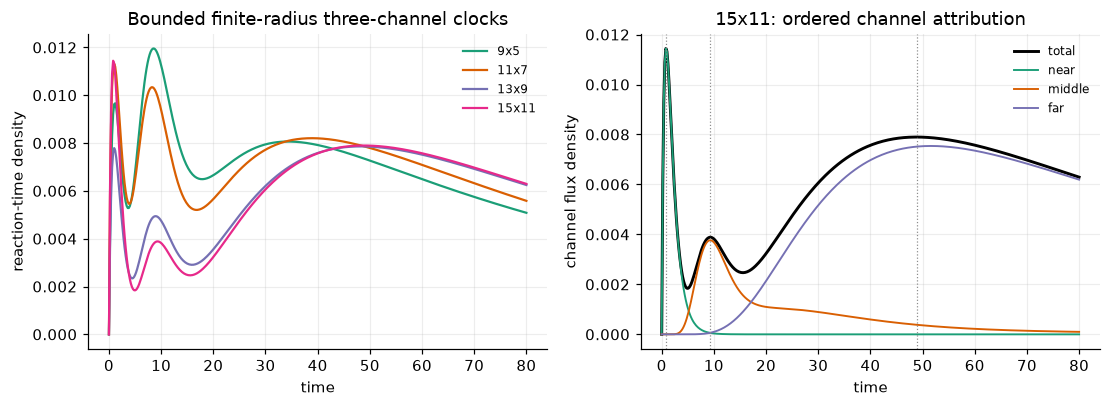

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.8))
grid_colors = {
    "9x5": "#1B9E77", "11x7": "#D95F02",
    "13x9": "#7570B3", "15x11": "#E7298A",
}
for row in trimodal_rows:
    label = f"{row['nx']}x{row['ny']}"
    prefix = f"g{label}"
    times = trimodal_2d_series[f"{prefix}_times"]
    visible = times <= 80.0
    axes[0].plot(
        times[visible],
        trimodal_2d_series[f"{prefix}_total_density"][visible],
        lw=1.45,
        color=grid_colors[label],
        label=label,
    )
axes[0].set(
    xlabel="time", ylabel="reaction-time density",
    title="Bounded finite-radius three-channel clocks",
)
axes[0].legend(frameon=False, fontsize=8)

finest_trimodal = trimodal_rows[-1]
finest_label = f"{finest_trimodal['nx']}x{finest_trimodal['ny']}"
prefix = f"g{finest_label}"
times = trimodal_2d_series[f"{prefix}_times"]
visible = times <= 80.0
total = trimodal_2d_series[f"{prefix}_total_density"]
channels = trimodal_2d_series[f"{prefix}_channel_density"]
axes[1].plot(times[visible], total[visible], color="black", lw=1.9, label="total")
for channel, label, color in zip(
    range(3), ["near", "middle", "far"],
    ["#1B9E77", "#D95F02", "#7570B3"], strict=True,
):
    axes[1].plot(
        times[visible], channels[visible, channel],
        color=color, lw=1.25, label=label,
    )
for root_index in (0, 2, 4):
    axes[1].axvline(
        finest_trimodal["detected_root_times"][root_index],
        color="0.55", ls=":", lw=0.8,
    )
axes[1].set(
    xlabel="time", ylabel="channel flux density",
    title=f"{finest_label}: ordered channel attribution",
)
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

This is a bounded-domain result for four finite CTMC grids with the
arithmetic midpoint reaction-centre convention. It supports a
spatial three-clock mechanism, with resolved trimodality on the
three finer grids and a coarse three-maximum shoulder. The patch masks are not cell-averaged,
so neither a continuum trimodality theorem nor a converged continuum
phase boundary is inferred.

### 8. Validate spectral necessity and fixed-budget modality design

In [11]:
design_finite = modality_design["finite_ctmc_cross_checks"]
design_encounter = modality_design["encounter_fold_application"]
design_checks = {
    "duhamel_matches_frechet": design_finite["duhamel_relative_l2_error"] < 2e-11,
    "basis_gradient_is_linear": design_finite["maximum_gradient_linearity_relative_error"] < 2e-11,
    "held_out_five_point": design_finite["maximum_five_point_relative_error"] < 2e-7,
    "permutation_equivariant": design_finite["permutation_equivariance_relative_error"] < 2e-11,
    "closed_form_beats_random": design_finite["best_random_over_optimum"] < 1.0,
    "encounter_chain_rule": design_encounter["theta_chain_rule_relative_error"] < 2e-9,
    "budget_direction_transverse": abs(design_encounter["fixed_state_sum_budget_transversality"]) > 1e-8,
}
assert all(design_checks.values()), design_checks

spectral_cases = pd.DataFrame([
    {
        "case": row["case"],
        "states": row["state_count"],
        "critical points": row["critical_point_count"],
        "minimum retained sign variations": row["minimum_retained_sign_variations"],
        "max density reconstruction error": max(
            item["density_relative_error"] for item in row["reconstruction"]
        ),
    }
    for row in spectral_modality["production_cases"]
])
spectral_checks = {
    "encounter_necessity": int(
        spectral_cases.loc[
            spectral_cases["case"] == "finite_encounter_supercritical",
            "minimum retained sign variations",
        ].iloc[0]
    ) >= 3,
    "trimodal_necessity": int(
        spectral_cases.loc[
            spectral_cases["case"] == "M2D-T_9x5",
            "minimum retained sign variations",
        ].iloc[0]
    ) >= 5,
    "hypoexponential_not_sufficient": (
        spectral_modality["hypoexponential_non_sufficiency"]["sign_variations"] == 3
        and "not sufficient" in spectral_modality["hypoexponential_non_sufficiency"]["conclusion"]
    ),
    "rank_one_is_bimodal": [
        row["type"]
        for row in spectral_modality["rank_one_killing_bimodality"]["critical_points"]
    ] == ["maximum", "minimum", "maximum"],
    "coefficient_inventory_complete": len(spectral_coefficients) == 961 + 2025,
}
assert all(spectral_checks.values()), spectral_checks
display(pd.DataFrame([design_checks]).T.rename(columns={0: "pass"}))
display(spectral_cases)
print(
    "General finite-model design audit: PASS — the spectral rule is "
    "necessary, not sufficient; the budget gradient predicts a "
    "production-fold unfolding direction."
)

,pass
duhamel_matches_frechet,True
basis_gradient_is_linear,True
held_out_five_point,True
permutation_equivariant,True
closed_form_beats_random,True
encounter_chain_rule,True
budget_direction_transverse,True


,case,states,critical points,minimum retained sign variations,max density reconstruction error
0,finite_encounter_supercritical,961,3,444,8.826833e-06
1,M2D-T_9x5,2025,5,191,4.483780e-11


General finite-model design audit: PASS — the spectral rule is necessary, not sufficient; the budget gradient predicts a production-fold unfolding direction.


The residue rule is a classical generalized-Descartes corollary for
finite real-diagonalizable spectra.  It is not a new theorem and is
not extended here to complex/Jordan or continuum spectra.  The
projected gradient is an infinitesimal interior-rate optimum; box,
positivity, binary-mask, moving-support, and finite-amplitude
constraints remain outside this validation.

### 9. Validate the multidimensional 2/3/4-mode GIG screen

In [12]:
multid_cases = pd.DataFrame(multid_gig["cases"])
multid_checks = {
    "twelve_cases": multid_gig["case_count"] == 12 and len(multid_cases) == 12,
    "dimensions_1_to_4": set(multid_cases["dimension"]) == {1, 2, 3, 4},
    "channel_counts_2_to_4": set(multid_cases["channel_count"]) == {2, 3, 4},
    "one_mode_per_channel": (
        multid_gig["all_cases_have_one_detected_mode_per_channel"]
        and multid_cases["resolved_mode_count"].eq(multid_cases["channel_count"]).all()
    ),
    "expected_simple_root_count": multid_cases["isolated_root_count"].eq(
        2 * multid_cases["channel_count"] - 1
    ).all(),
    "small_derivative_residual": multid_cases["max_scaled_derivative_residual"].max() < 3e-13,
    "resolved_valleys": multid_cases["minimum_peak_to_valley_ratio"].min() > 1.9,
    "bounded_domain_not_claimed": "bounded-domain PDE theorem" in multid_gig["not_claimed"],
}
assert all(multid_checks.values()), multid_checks
gig_bounded_domain_trimodality_claimed = False
bounded_trimodality_claimed = bounded_continuum_trimodality_theorem_claimed

multid_view = multid_cases.pivot(
    index="dimension", columns="channel_count", values="resolved_mode_count"
)
display(multid_cases[[
    "dimension", "channel_count", "resolved_mode_count",
    "isolated_root_count", "minimum_peak_to_valley_ratio",
    "max_scaled_derivative_residual",
]])
print(
    "Free-space GIG screen: PASS — 12/12 dimension/channel designs "
    "resolve one mode per channel. A bounded-domain conclusion from "
    "this GIG screen is claimed: FALSE."
)

,dimension,channel_count,resolved_mode_count,isolated_root_count,minimum_peak_to_valley_ratio,max_scaled_derivative_residual
0,1,2,2,3,1.996154,3.641019e-15
1,1,3,3,5,1.996154,2.975576e-14
2,1,4,4,7,1.996154,7.739804e-15
3,2,2,2,3,2.695648,5.328589e-15
4,2,3,3,5,2.695648,2.136319e-14
5,2,4,4,7,2.695648,1.745984e-13
6,3,2,2,3,3.653129,1.535284e-15
7,3,3,3,5,3.653129,5.162394e-14
8,3,4,4,7,3.653129,4.663427e-14
9,4,2,2,3,4.959766,4.608783e-16


Free-space GIG screen: PASS — 12/12 dimension/channel designs resolve one mode per channel. A bounded-domain conclusion from this GIG screen is claimed: FALSE.


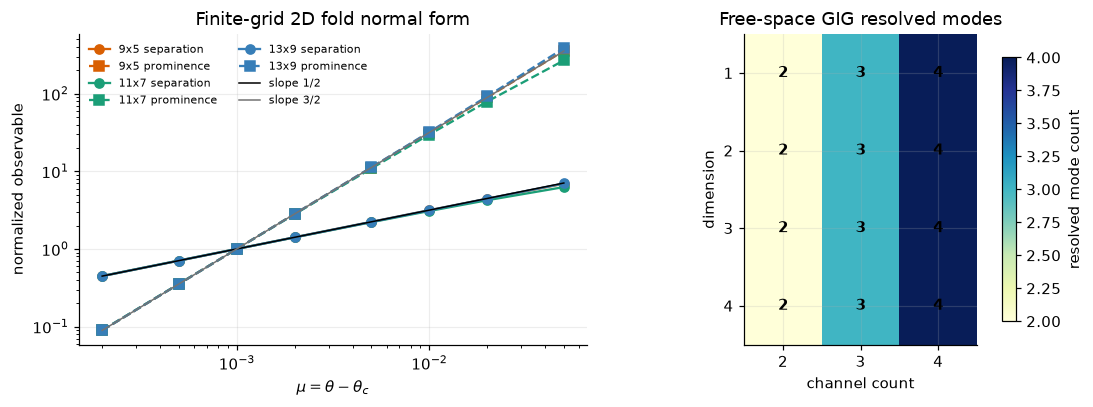

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.8))
colors_2d = {
    "9x5": "#D95F02",
    "11x7": "#1B9E77",
    "13x9": "#377EB8",
}
for row in fold_2d["grids"]:
    grid_label = f"{row['grid'][0]}x{row['grid'][1]}"
    scaling_rows = pd.DataFrame(row["scaling_rows"])
    reference = scaling_rows.iloc[2]
    axes[0].loglog(
        scaling_rows["mu"],
        scaling_rows["separation"] / reference["separation"],
        "o-", color=colors_2d[grid_label], label=f"{grid_label} separation",
    )
    axes[0].loglog(
        scaling_rows["mu"],
        scaling_rows["prominence"] / reference["prominence"],
        "s--", color=colors_2d[grid_label], label=f"{grid_label} prominence",
    )
mu = pd.DataFrame(fold_2d["grids"][0]["scaling_rows"])["mu"].to_numpy()
reference_mu = mu[2]
axes[0].loglog(mu, (mu/reference_mu)**0.5, color="black", lw=1.0, label="slope 1/2")
axes[0].loglog(mu, (mu/reference_mu)**1.5, color="0.45", lw=1.0, label="slope 3/2")
axes[0].set(xlabel=r"$\mu=\theta-\theta_c$", ylabel="normalized observable",
            title="Finite-grid 2D fold normal form")
axes[0].legend(frameon=False, fontsize=7, ncol=2)

image = axes[1].imshow(multid_view.to_numpy(), cmap="YlGnBu", vmin=2, vmax=4)
axes[1].set_xticks(range(len(multid_view.columns)), multid_view.columns)
axes[1].set_yticks(range(len(multid_view.index)), multid_view.index)
axes[1].set(xlabel="channel count", ylabel="dimension",
            title="Free-space GIG resolved modes")
for iy, dimension in enumerate(multid_view.index):
    for ix, channels in enumerate(multid_view.columns):
        axes[1].text(ix, iy, int(multid_view.loc[dimension, channels]),
                     ha="center", va="center", color="black", fontweight="bold")
fig.colorbar(image, ax=axes[1], label="resolved mode count", shrink=0.85)
fig.tight_layout()
plt.show()

### 10. Validate patterned versus matched homogeneous 2D reactivity

In [14]:
matched_checks = {
    "family_is_m2d_e": matched["family_id"].eq("M2D-E").all(),
    "one_correlated_family": matched["branch_id"].eq(
        "equal_budget_endpoint_amplification"
    ).all(),
    "five_grids": len(matched) == 5,
    "patterned_coarse_shoulder_four_finer_bimodal": (
        matched.sort_values(["nx", "ny"])
        ["patterned_classification"].tolist()
        == ["shoulder", "bimodal", "bimodal", "bimodal", "bimodal"]
    ),
    "homogeneous_resolved_unimodal_all_grids": matched["homogeneous_resolved_classification"].eq("resolved_unimodal").all(),
    "strict_secondary_maxima_retained": (
        matched["patterned_strict_mode_count"].eq(2).all()
        and matched["homogeneous_strict_mode_count"].eq(2).all()
    ),
    "homogeneous_secondary_modes_subthreshold": (
        matched["homogeneous_strict_secondary_peak_ratio"].gt(0.0).all()
        and matched["homogeneous_strict_secondary_peak_ratio"].lt(0.03).all()
    ),
    "product_trapezoidal_control_non_bimodal": (
        matched[
            "product_trapezoidal_homogeneous_resolved_classification"
        ].isin(["resolved_unimodal", "resolved_shoulder"]).all()
        and matched[
            "product_trapezoidal_homogeneous_positive_scale_views"
        ].eq(0).all()
        and matched[
            "product_trapezoidal_homogeneous_strict_secondary_peak_ratio"
        ].lt(0.03).all()
    ),
    "strict_ratio_interval_nonempty": (
        matched["strict_secondary_ratio_interval_lower"].nunique() == 1
        and matched["strict_secondary_ratio_interval_upper"].nunique() == 1
        and matched["strict_secondary_ratio_interval_lower"].iloc[0] < 0.03
        < matched["strict_secondary_ratio_interval_upper"].iloc[0]
        and matched["strict_secondary_ratio_interval_margin"].iloc[0] > 0.026
    ),
    "recorded_101_cutoff_sweep_passes": all(
        row["sample_count"] == 101
        and row["all_sampled_cutoffs_match_expected"]
        and "finite recorded cutoff sample" in row["scope"]
        for row in matched["classifier_cutoff_sweep"]
    ),
    "integrated_killing_matched": matched["integrated_killing_relative_error"].max() < 1e-12,
    "product_trapezoidal_budget_matched": (
        matched["product_trapezoidal_budget_relative_error"].max()
        < 1e-12
    ),
    "finite_lattice_resolution_boundary_recorded": all(
        row["walker_one"]["cell_peclet_x"] >= 4.5
        and "finite-lattice family" in row["interpretation"]
        for row in matched["resolution_diagnostics"]
    ),
    "no_post_window_maxima": (
        matched["patterned_post_window_local_maxima"].eq(0).all()
        and matched["homogeneous_post_window_local_maxima"].eq(0).all()
        and matched[
            "product_trapezoidal_homogeneous_post_window_local_maxima"
        ].eq(0).all()
    ),
    "tails_checked": (
        matched["patterned_tail_at_960"].max() < 2e-10
        and matched["homogeneous_tail_at_960"].max() < 1e-20
        and matched[
            "product_trapezoidal_homogeneous_tail_at_960"
        ].max() < 1e-8
    ),
}
assert all(matched_checks.values()), matched_checks

matched_view = matched[[
    "nx", "ny", "product_states",
    "patterned_classification", "homogeneous_classification",
    "patterned_strict_mode_count", "homogeneous_strict_mode_count",
    "homogeneous_strict_secondary_peak_ratio",
    "product_trapezoidal_homogeneous_strict_secondary_peak_ratio",
    "patterned_strict_secondary_peak_ratio",
    "patterned_peak_early", "patterned_peak_late", "homogeneous_peak",
    "patterned_positive_scale_views", "scale_views",
    "integrated_killing_relative_error",
    "product_trapezoidal_budget_relative_error",
]]
display(matched_view)
print(
    "M2D-E matched endpoint audit: PASS — all five homogeneous controls are "
    "resolved-unimodal; four finer patterned endpoints are bimodal "
    "and the coarse patterned endpoint is a shoulder; strict "
    "secondary maxima are retained. The full classifier preserves "
    "those calls at 101 recorded cutoffs inside "
    f"({100*matched['strict_secondary_ratio_interval_lower'].iloc[0]:.2f}%, "
    f"{100*matched['strict_secondary_ratio_interval_upper'].iloc[0]:.2f}%); "
    "no continuous-interval claim is made. Max "
    "state-sum/control-volume killing mismatches "
    f"{matched['integrated_killing_relative_error'].max():.2e}/"
    f"{matched['product_trapezoidal_budget_relative_error'].max():.2e}."
)

,nx,ny,product_states,patterned_classification,homogeneous_classification,patterned_strict_mode_count,homogeneous_strict_mode_count,homogeneous_strict_secondary_peak_ratio,product_trapezoidal_homogeneous_strict_secondary_peak_ratio,patterned_strict_secondary_peak_ratio,patterned_peak_early,patterned_peak_late,homogeneous_peak,patterned_positive_scale_views,scale_views,integrated_killing_relative_error,product_trapezoidal_budget_relative_error
0,9,5,2025,shoulder,unimodal,2,2,0.016525,0.006366,0.044346,1.2,17.816461,1.1,123,155,4.104218e-16,0.000000e+00
1,11,7,5929,bimodal,unimodal,2,2,0.014372,0.007828,0.063851,1.3,19.500000,1.1,153,155,3.080944e-16,1.353931e-16
2,13,9,13689,bimodal,unimodal,2,2,0.018099,0.011662,0.081475,1.5,20.700000,1.1,155,155,3.507049e-16,0.000000e+00
3,15,11,27225,bimodal,unimodal,2,2,0.017157,0.012167,0.075435,1.5,20.800000,1.2,155,155,0.000000e+00,0.000000e+00
4,17,13,48841,bimodal,unimodal,2,2,0.010229,0.007210,0.076260,1.3,19.200000,1.1,152,155,2.232711e-16,0.000000e+00


M2D-E matched endpoint audit: PASS — all five homogeneous controls are resolved-unimodal; four finer patterned endpoints are bimodal and the coarse patterned endpoint is a shoulder; strict secondary maxima are retained. The full classifier preserves those calls at 101 recorded cutoffs inside (1.81%, 4.43%); no continuous-interval claim is made. Max state-sum/control-volume killing mismatches 4.10e-16/1.35e-16.


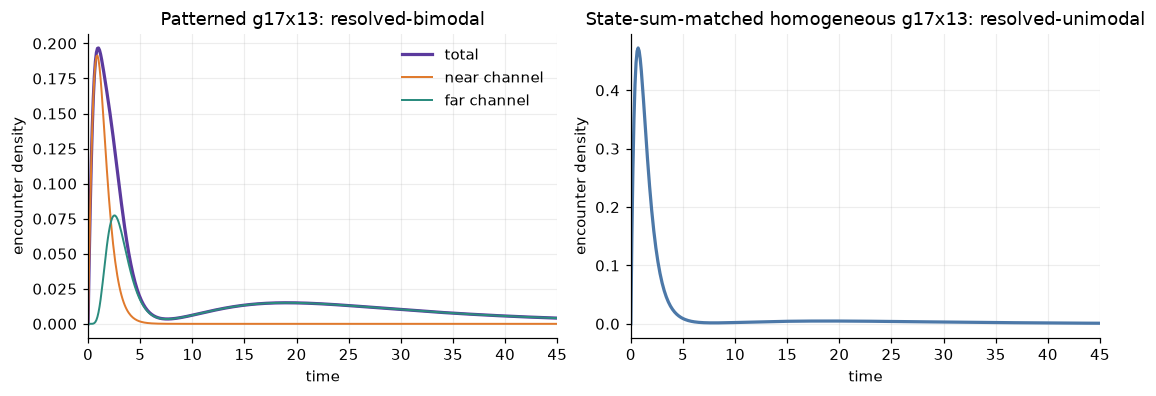

In [15]:
finest = matched.sort_values(["nx", "ny"]).iloc[-1]
prefix = f"g{int(finest.nx)}x{int(finest.ny)}"
patterned_t = matched_series[f"{prefix}_patterned_times"]
patterned_f = matched_series[f"{prefix}_patterned_density"]
patterned_channels = matched_series[f"{prefix}_patterned_channels"]
homogeneous_t = matched_series[f"{prefix}_homogeneous_times"]
homogeneous_f = matched_series[f"{prefix}_homogeneous_density"]

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.7), sharex=True)
axes[0].plot(patterned_t, patterned_f, color="#5B3A9D", lw=2.1, label="total")
axes[0].plot(patterned_t, patterned_channels[:, 0], color="#E07A2D", lw=1.3, label="near channel")
axes[0].plot(patterned_t, patterned_channels[:, 1], color="#2B8C7E", lw=1.3, label="far channel")
axes[0].set(title=f"Patterned {prefix}: resolved-bimodal", xlabel="time", ylabel="encounter density")
axes[0].legend(frameon=False)

axes[1].plot(homogeneous_t, homogeneous_f, color="#4C78A8", lw=2.1)
axes[1].set(title=f"State-sum-matched homogeneous {prefix}: resolved-unimodal",
            xlabel="time", ylabel="encounter density")
for ax in axes:
    ax.set_xlim(0, 45)
fig.tight_layout()
plt.show()

### 11. Recompute the finite-grid 2D logarithmic-slope check

In [16]:
recomputed_2d = []
for grid_n, group in capacity_2d_rows.groupby("grid_n", sort=True):
    x = np.log(1.0 / group["radius"].to_numpy())
    y = group["mean_time"].to_numpy()
    slope, intercept = np.polyfit(x, y, 1)
    prediction = slope * x + intercept
    r_squared = 1.0 - np.sum((y - prediction) ** 2) / np.sum((y - y.mean()) ** 2)
    saved = capacity_2d_fits.loc[capacity_2d_fits["grid_n"] == grid_n].iloc[0]
    assert np.isclose(slope, saved["fitted_log_slope"], atol=1e-13)
    assert np.isclose(r_squared, saved["r_squared"], atol=1e-13)
    recomputed_2d.append({
        "grid_n": int(grid_n),
        "spacing": saved["spacing"],
        "recomputed_slope": slope,
        "theory_slope": saved["theory_log_slope"],
        "slope_ratio_to_theory": slope / saved["theory_log_slope"],
        "r_squared": r_squared,
    })
capacity_2d_check = pd.DataFrame(recomputed_2d)
finest_2d = capacity_2d_check.iloc[-1]
assert finest_2d["slope_ratio_to_theory"] > 0.98
assert finest_2d["r_squared"] > 0.9999
assert capacity_2d_summary["summary_checks"]["finite_grid_slope_consistency_pass"] is True
assert capacity_2d_summary["numerical_method"]["fixed_radius_and_grid_limits_separated"] is False
assert capacity_2d_summary["summary_checks"]["continuum_capacity_coefficient_certified"] is False
display(capacity_2d_check)
print(
    "2D capacity check: PASS — finest slope/theory = "
    f"{finest_2d['slope_ratio_to_theory']:.6f} "
    f"(relative error {1-finest_2d['slope_ratio_to_theory']:.3%})."
)

,grid_n,spacing,recomputed_slope,theory_slope,slope_ratio_to_theory,r_squared
0,161,0.006211,0.151149,0.159155,0.949695,0.999429
1,241,0.004149,0.155811,0.159155,0.978987,0.999906
2,321,0.003115,0.156590,0.159155,0.983883,0.999958
3,401,0.002494,0.156740,0.159155,0.984829,0.999961


2D capacity check: PASS — finest slope/theory = 0.984829 (relative error 1.517%).


### 12. Recompute the 3D inverse-effective-radius slope

In [17]:
def linear_fit(frame: pd.DataFrame) -> tuple[float, float, float]:
    x = 1.0 / frame["effective_radius"].to_numpy()
    y = frame["mean_time"].to_numpy()
    slope, intercept = np.polyfit(x, y, 1)
    prediction = slope * x + intercept
    r_squared = 1.0 - np.sum((y - prediction) ** 2) / np.sum((y - y.mean()) ** 2)
    return float(slope), float(intercept), float(r_squared)

slope_all, intercept_all, r2_all = linear_fit(capacity_3d_rows)
smallest_four = capacity_3d_rows.nsmallest(4, "reaction_radius")
slope_small, intercept_small, r2_small = linear_fit(smallest_four)
theory_3d = capacity_3d_summary["theory"]["theory_inverse_effective_radius_slope"]

assert np.isclose(slope_all, capacity_3d_summary["radius_fit_all"]["slope"], atol=1e-13)
assert np.isclose(slope_small, capacity_3d_summary["radius_fit_smallest_four"]["slope"], atol=1e-13)
assert slope_small / theory_3d > 0.998
assert r2_small > 0.99999
assert capacity_3d_rows.sort_values("reaction_radius")["mean_over_leading_mean"].iloc[0] > 0.96
assert capacity_3d_summary["summary_checks"]["finest_grid_pair_relative_difference"] < 1e-3
assert capacity_3d_summary["numerical_method"]["fixed_chi_radius_and_grid_limits_separated"] is False
assert capacity_3d_summary["summary_checks"]["continuum_capacity_coefficient_certified"] is False
assert capacity_3d_summary["summary_checks"]["coupled_path_is_continuum_compatible"] is True

capacity_3d_check = pd.DataFrame([
    {"fit": "all six radii", "slope": slope_all, "slope/theory": slope_all/theory_3d, "R2": r2_all},
    {"fit": "smallest four radii", "slope": slope_small, "slope/theory": slope_small/theory_3d, "R2": r2_small},
])
display(capacity_3d_check)
print(
    "3D coupled-path compatibility check: PASS — smallest-four slope/theory = "
    f"{slope_small/theory_3d:.6f}; finest fixed-radius grid-pair difference = "
    f"{capacity_3d_summary['summary_checks']['finest_grid_pair_relative_difference']:.3e}."
)

,fit,slope,slope/theory,R2
0,all six radii,0.079351,0.997160,0.999998
1,smallest four radii,0.079486,0.998856,1.000000


3D coupled-path compatibility check: PASS — smallest-four slope/theory = 0.998856; finest fixed-radius grid-pair difference = 6.509e-04.


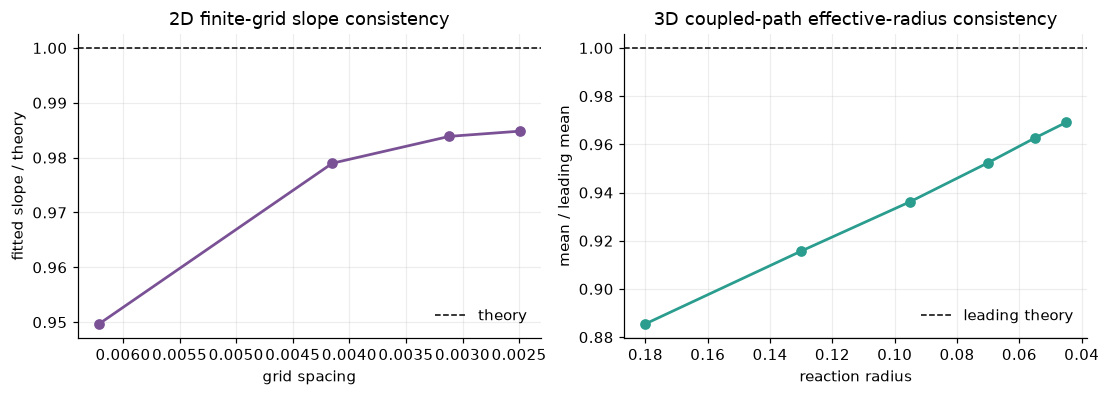

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.7))
axes[0].plot(capacity_2d_check["spacing"], capacity_2d_check["slope_ratio_to_theory"],
             marker="o", color="#7A5195", lw=1.8)
axes[0].axhline(1.0, color="black", ls="--", lw=1.0, label="theory")
axes[0].set(xlabel="grid spacing", ylabel="fitted slope / theory",
            title="2D finite-grid slope consistency")
axes[0].invert_xaxis()
axes[0].legend(frameon=False)

radius_order = capacity_3d_rows.sort_values("reaction_radius", ascending=False)
axes[1].plot(radius_order["reaction_radius"], radius_order["mean_over_leading_mean"],
             marker="o", color="#2A9D8F", lw=1.8)
axes[1].axhline(1.0, color="black", ls="--", lw=1.0, label="leading theory")
axes[1].set(xlabel="reaction radius", ylabel="mean / leading mean",
            title="3D coupled-path effective-radius consistency")
axes[1].invert_xaxis()
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

### 13. Claim-to-evidence ledger

In [19]:
claim_rows = [
    {
        "claim": "Finite reversible spectral sign-variation necessity",
        "evidence": "spectral_modality_summary.json; spectral_modality_coefficients.csv",
        "status": "PASS" if all(spectral_checks.values()) else "FAIL",
        "scope boundary": (
            "Classical necessary corollary only; not sufficient and not "
            "a nonreversible, Jordan, channel-rank, or continuum theorem"
        ),
    },
    {
        "claim": "Fixed-budget local modality-gradient optimizer",
        "evidence": "modality_susceptibility_summary.json",
        "status": "PASS" if all(design_checks.values()) else "FAIL",
        "scope boundary": (
            "Exact infinitesimal finite-state interior-rate design; no "
            "finite-amplitude mask/shape or continuum optimum"
        ),
    },
    {
        "claim": "Nondegenerate physical-control modality fold",
        "evidence": "gig_fold_summary.json; gig_fold_continuation.csv",
        "status": "PASS" if all(fold_checks.values()) else "FAIL",
        "scope boundary": (
            "Numerically verified for the stated finite L=31 CTMC "
            "using exact finite-matrix derivative identities"
        ),
    },
    {
        "claim": "Held-out fold normal-form exponents",
        "evidence": "gig_fold_continuation.csv",
        "status": "PASS" if fold_checks["held_out_separation_near_half"] and fold_checks["held_out_prominence_near_three_halves"] else "FAIL",
        "scope boundary": "Numerical local scaling; no continuum remainder bound",
    },
    {
        "claim": "Finite Green dark-mode/pole/residue exclusions",
        "evidence": "finite_matrix_green_spectral_audit.json",
        "status": "PASS" if all(green_spectral_checks.values()) else "FAIL",
        "scope boundary": (
            "Exact 4x4 rational matrix fixture; no continuum meromorphic continuation"
        ),
    },
    {
        "claim": "M2D-F matched-budget finite-radius fold mechanism and endpoints",
        "evidence": "finite_radius_2d_fold_metrics.json",
        "status": "PASS" if (
            fold_2d_max_residual < 5e-14
            and fold_2d_max_dimensionless_residual < 1e-8
            and fold_2d_nondegenerate
            and fold_2d_scaling_pass
            and fold_2d_side_controls_pass
            and fold_2d_budget_pass
            and all(weighted_budget_checks.values())
            and all(topology_checks.values())
            and all(finite_lattice_resolution_checks.values())
            and all(endpoint_2d_checks.values())
        ) else "FAIL",
        "scope boundary": (
            "Finite-lattice mechanism certificate only; theta_c is "
            "grid- and budget-measure-sensitive"
        ),
    },
    {
        "claim": "M2D-C separated-boundary four-grid branch",
        "evidence": "finite_radius_2d_metrics.json",
        "status": "PASS" if all(base_checks.values()) else "FAIL",
        "scope boundary": (
            "Four declared finite grids; 9x5 remains conditional on its "
            "strict tail gate; the 11x7 control curve is the same model, "
            "not independent evidence; no controlled-refinement claim"
        ),
    },
    {
        "claim": "Remaining M2D-C spatial and transport controls",
        "evidence": (
            "finite_radius_2d_control_metrics.json; "
            "finite_radius_2d_interior_metrics.json; "
            "finite_radius_2d_domain_scaling.json"
        ),
        "status": "PASS" if all(controls_checks.values()) else "FAIL",
        "scope boundary": (
            "Finite-grid examples; patterning is not necessary for "
            "every bimodal density. Domain scaling is consistent with, "
            "not a pathwise proof of, a return-clock interpretation; "
            "the finite derivative scan is not interval-exhaustive"
        ),
    },
    {
        "claim": "Catalytic-coordinate convention is observable and non-equivalent",
        "evidence": "finite_radius_2d_centre_coordinate.json",
        "status": "PASS" if all(coordinate_checks.values()) else "FAIL",
        "scope boundary": (
            "Three finite principal grids plus one supplemental grid; "
            "no continuum robustness claim"
        ),
    },
    {
        "claim": "Bounded finite-radius 2D three-clock structure and trimodality subset",
        "evidence": "finite_radius_2d_trimodal_metrics.json/.npz",
        "status": "PASS" if all(trimodal_checks.values()) else "FAIL",
        "scope boundary": (
            "Three resolved trimodal grids plus one shoulder with five "
            "detected alternating roots; "
            "not a continuum theorem or phase boundary"
        ),
    },
    {
        "claim": "Free-space multidimensional 2/3/4-mode GIG screen",
        "evidence": "multid_gig_design_summary.json",
        "status": "PASS" if all(multid_checks.values()) else "FAIL",
        "scope boundary": "12 screening constructions; bounded trimodality not claimed",
    },
    {
        "claim": "M2D-E patterning amplifies a matched transport clock",
        "evidence": "finite_radius_2d_matched_control.csv/.npz",
        "status": "PASS" if all(matched_checks.values()) else "FAIL",
        "scope boundary": (
            "Five finite grids; equal per-lattice discrete state-sum "
            "killing only; no M2D-E fold or continuum match"
        ),
    },
    {
        "claim": "2D finite-grid logarithmic-slope consistency",
        "evidence": "finite_radius_2d_capacity_rows.csv",
        "status": "PASS" if (
            finest_2d["slope_ratio_to_theory"] > 0.98
            and finest_2d["r_squared"] > 0.9999
            and capacity_2d_summary["numerical_method"][
                "fixed_radius_and_grid_limits_separated"
            ] is False
            and capacity_2d_summary["summary_checks"][
                "continuum_capacity_coefficient_certified"
            ] is False
        ) else "FAIL",
        "scope boundary": (
            "Translation-invariant finite-grid benchmark; radius/grid "
            "limits not independently extrapolated; no certified "
            "continuum coefficient"
        ),
    },
    {
        "claim": "3D coupled-path Doi effective-radius consistency",
        "evidence": "finite_radius_3d_radius_convergence.csv",
        "status": "PASS" if (
            slope_small/theory_3d > 0.998
            and r2_small > 0.99999
            and capacity_3d_summary["numerical_method"][
                "fixed_chi_radius_and_grid_limits_separated"
            ] is False
            and capacity_3d_summary["summary_checks"][
                "continuum_capacity_coefficient_certified"
            ] is False
            and capacity_3d_summary["summary_checks"][
                "coupled_path_is_continuum_compatible"
            ] is True
        ) else "FAIL",
        "scope boundary": (
            "Translation-invariant coupled finite-grid path; no separated "
            "double limit, certified continuum coefficient, or 6D "
            "patterned fold"
        ),
    },
]
claim_table = pd.DataFrame(claim_rows)
assert claim_table["status"].eq("PASS").all()
display(claim_table)

,claim,evidence,status,scope boundary
0,Finite reversible spectral sign-variation nece...,spectral_modality_summary.json; spectral_modal...,PASS,Classical necessary corollary only; not suffic...
1,Fixed-budget local modality-gradient optimizer,modality_susceptibility_summary.json,PASS,Exact infinitesimal finite-state interior-rate...
2,Nondegenerate physical-control modality fold,gig_fold_summary.json; gig_fold_continuation.csv,PASS,Numerically verified for the stated finite L=3...
3,Held-out fold normal-form exponents,gig_fold_continuation.csv,PASS,Numerical local scaling; no continuum remainde...
4,Finite Green dark-mode/pole/residue exclusions,finite_matrix_green_spectral_audit.json,PASS,Exact 4x4 rational matrix fixture; no continuu...
5,M2D-F matched-budget finite-radius fold mechan...,finite_radius_2d_fold_metrics.json,PASS,Finite-lattice mechanism certificate only; the...
6,M2D-C separated-boundary four-grid branch,finite_radius_2d_metrics.json,PASS,Four declared finite grids; 9x5 remains condit...
7,Remaining M2D-C spatial and transport controls,finite_radius_2d_control_metrics.json; finite_...,PASS,Finite-grid examples; patterning is not necess...
8,Catalytic-coordinate convention is observable ...,finite_radius_2d_centre_coordinate.json,PASS,Three finite principal grids plus one suppleme...
9,Bounded finite-radius 2D three-clock structure...,finite_radius_2d_trimodal_metrics.json/.npz,PASS,Three resolved trimodal grids plus one shoulde...


## Takeaways

- **Finite CTMC fold:** supported by direct derivative residuals,
  nondegeneracy, side controls, and held-out $1/2$ and $3/2$ slopes.
  Its minority near-channel splitting probability is only about
  $8.95\times10^{-6}$, so practical observability remains a caveat.
- **Finite Green spectral boundary:** an exact $4\times4$ fixture verifies
  a shared dark mode, a coupled $\det(I+GK)$ pole, and nonzero channel
  residues that cancel in total flux.  It validates the finite
  warning only; continuum meromorphic continuation is false as a
  claimed result.
- **M2D-C branch and control boundary:** the separated-boundary
  branch is bimodal on four declared grids, but the coarse
  $9\times5$ case remains conditional on its tail gate. Its
  $11\times7$ curve is reused by the control artifact and is not
  independent evidence. The remaining M2D-C branches include
  bimodal interior and uniform-reactivity examples; single-far and
  co-located controls are resolved-unimodal despite shallow strict
  secondary maxima. The domain-length fit is descriptive and
  consistent with a first-pass/boundary-return interpretation; all
  rows pass a separate $t=480$ tail/derivative gate, but the scan is
  not interval-exhaustive. Its $L_x=1$ row is the same uniform
  control, not independent evidence. Patterning is therefore not
  necessary.
- **M2D-E mechanism:** all five matched homogeneous endpoints are
  resolved-unimodal; four finer patterned endpoints are bimodal and
  the coarse patterned endpoint is a shoulder with a retained strict
  second maximum. Killing-rate mismatch is at floating-point roundoff,
  and a recorded 101-cutoff full-classifier sweep preserves these
  calls. This is finite-grid evidence for clock amplification under
  the stated match, not a continuous-cutoff or continuum theorem.
- **M2D-F matched-budget fold:** all three fold grids have residuals
  at numerical precision, nonzero $f_{ttt}$ and $f_{t\theta}$, and
  $1/2$ and $3/2$ local exponents. Its five-grid endpoint audit has
  homogeneous resolved-unimodal and patterned resolved-bimodal calls
  on every grid. Their state-count-matched
  $\theta_c$ values span about $0.262$, and product-control-volume
  matching moves all three while retaining nondegenerate folds.
  The coordinate is neither grid-converged nor measure-invariant,
  so no continuum $\theta_c$ is reported.
- **Catalytic coordinate:** midpoint and diffusivity-weighted
  coordinates generate different patch masks and quantitative
  densities. Both give a shoulder on $9\times5$ and bimodality on
  two finer grids; label agreement does not imply model equivalence
  or continuum robustness.
- **Bounded three-channel clocks:** one fixed reflecting-rectangle
  Doi model has three strict modes and five detected sign-changing
  derivative roots of alternating type on four grids. The classifier resolves all three
  on the three finer grids and calls the coarsest a shoulder. The
  maxima are respectively dominated by the near, middle, and far
  patches. Every patch radius remains below the longitudinal
  spacing and reactive-state counts are nonmonotone.  This is a
  finite-grid bounded-domain mechanism certificate; the finite scan
  is not interval-exhaustive, and no continuum theorem or phase
  boundary is claimed.
- **Multimode screening boundary:** all 12 free-space GIG designs in
  dimensions 1--4 resolve 2, 3, or 4 modes as designed.  This is an
  analytic/numerical screening construction; physical realization of
  its designed mixture weights is not claimed by that screen.
- **Dimensional calibration:** finite-grid fitted slopes and ratios
  are consistent with the 2D logarithmic-capacity and 3D Doi
  effective-radius predictions along the sampled/coupled paths in
  the translation-invariant quotient benchmarks. The radius and
  grid limits are not independently extrapolated, so continuum
  coefficients are not certified.
- **Publication boundary:** the combined artifacts justify finite-state
  folds, the M2D-F all-five endpoint contrast, the separate M2D-E
  five-grid amplification audit with four resolved contrasts, a
  three-grid bounded 2D resolved-trimodality certificate plus a fourth
  shoulder with five detected roots, free-space multimode screening, and
  multidimensional capacity calibration—not a theorem proving
  persistence of a patterned fold or a trimodality phase boundary in
  a bounded 2D or 3D continuum domain.

In [20]:
validation_summary = {
    "all_claims_pass": bool(claim_table["status"].eq("PASS").all()),
    "claim_count": int(len(claim_table)),
    "fold_max_dimensionless_residual": float(max(
        abs(physical_fold["dimensionless_first_residual"]),
        abs(physical_fold["dimensionless_second_residual"]),
    )),
    "fold_nondegenerate": bool(
        fold_checks["third_derivative_nondegenerate"]
        and fold_checks["parameter_transversality_nondegenerate"]
    ),
    "held_out_separation_slope": float(separation_slope),
    "held_out_prominence_slope": float(prominence_slope),
    "finite_green_spectral_all_checks_pass": bool(
        all(green_spectral_checks.values())
    ),
    "finite_green_dark_eigenvalue": float(dark["eigenvalue"]),
    "finite_green_coupled_pole": float(pole["eigenvalue"]),
    "finite_green_channel_residues": [
        float(value) for value in residues["channel_residues"]
    ],
    "finite_green_total_residue": float(
        residues["total_observable_residue"]
    ),
    "continuum_green_meromorphic_continuation_claimed": bool(
        continuum_green_meromorphic_continuation_claimed
    ),
    "modality_design_all_checks_pass": bool(all(design_checks.values())),
    "modality_design_best_random_over_optimum": float(
        design_finite["best_random_over_optimum"]
    ),
    "modality_design_encounter_chain_rule_relative_error": float(
        design_encounter["theta_chain_rule_relative_error"]
    ),
    "spectral_modality_all_checks_pass": bool(all(spectral_checks.values())),
    "spectral_modality_production_case_count": int(len(spectral_cases)),
    "spectral_modality_rank_one_bimodal": bool(
        spectral_checks["rank_one_is_bimodal"]
    ),
    "spectral_modality_sign_variation_sufficient_claimed": False,
    "finite_radius_2d_fold_grid_count": int(len(fold_2d_table)),
    "finite_radius_2d_fold_max_residual": fold_2d_max_residual,
    "finite_radius_2d_fold_max_dimensionless_residual": fold_2d_max_dimensionless_residual,
    "finite_radius_2d_fold_nondegenerate": fold_2d_nondegenerate,
    "finite_radius_2d_separation_exponents": [
        float(value) for value in fold_2d_table["separation exponent"]
    ],
    "finite_radius_2d_prominence_exponents": [
        float(value) for value in fold_2d_table["prominence exponent"]
    ],
    "finite_radius_2d_theta_c_drift": float(grid_comparison["theta_c_absolute_difference"]),
    "finite_radius_2d_weighted_theta_c_range": float(
        budget_sensitivity["weighted_theta_c_range"]
    ),
    "finite_radius_2d_weighted_folds_all_pass": bool(
        all(weighted_budget_checks.values())
    ),
    "finite_radius_2d_even_grid_topology_checks_pass": bool(
        all(topology_checks.values())
    ),
    "finite_radius_2d_continuum_refinement_claimed": False,
    "finite_radius_2d_fold_location_grid_converged": bool(
        grid_comparison["fold_location_grid_converged"]
    ),
    "finite_radius_2d_endpoint_grid_count": int(endpoint_2d["grid"].map(tuple).nunique()),
    "finite_radius_2d_resolved_endpoint_contrast": bool(all(endpoint_2d_checks.values())),
    "finite_radius_2d_base_all_checks_pass": bool(all(base_checks.values())),
    "finite_radius_2d_base_conditional_grid_count": int(
        base_rows["evidence_grade"].eq("conditional").sum()
    ),
    "finite_radius_2d_controls_all_checks_pass": bool(
        all(controls_checks.values())
    ),
    "finite_radius_2d_uniform_reactivity_bimodal": bool(
        control_by_case["uniform_reactivity"]["classification"]
        == "bimodal"
    ),
    "finite_radius_2d_interior_grid_count": int(len(interior_2d)),
    "finite_radius_2d_domain_scaling_r_squared": float(
        domain_2d["linear_fit"]["r_squared"]
    ),
    "finite_radius_2d_coordinate_grid_count": int(len(coordinate_rows)),
    "finite_radius_2d_coordinate_all_checks_pass": bool(all(coordinate_checks.values())),
    "finite_radius_2d_coordinate_changes_coarse_label": bool(
        coordinate_summary["coordinate_convention_changes_coarse_grid_modality"]
    ),
    "finite_radius_2d_coordinate_labels_agree_on_three_grids": bool(
        coordinate_summary["classification_change_grids"] == []
    ),
    "finite_radius_2d_coordinate_min_patch_jaccard": float(
        coordinate_summary["minimum_principal_patch_jaccard_distance"]
    ),
    "finite_radius_2d_coordinate_max_patch_jaccard": float(
        coordinate_summary["maximum_principal_patch_jaccard_distance"]
    ),
    "finite_radius_2d_coordinate_models_equivalent_claimed": bool(
        coordinate_models_equivalent_claimed
    ),
    "finite_radius_2d_coordinate_continuum_robustness_claimed": bool(
        coordinate_continuum_robustness_claimed
    ),
    "finite_radius_2d_trimodal_grid_count": int(len(trimodal_rows)),
    "finite_radius_2d_trimodal_resolved_grid_count": int(
        sum(row["mode_count"] == 3 for row in trimodal_rows)
    ),
    "finite_radius_2d_trimodal_all_four_have_five_detected_roots": bool(
        trimodal_cross["all_four_have_five_detected_alternating_roots"]
    ),
    "finite_radius_2d_trimodal_all_checks_pass": bool(all(trimodal_checks.values())),
    "finite_radius_2d_trimodal_support_underresolved": bool(
        trimodal_cross[
            "all_patch_disks_underresolved_longitudinally"
        ]
    ),
    "finite_radius_2d_trimodal_max_tail_at_2000": float(
        trimodal_cross["maximum_tail_at_2000"]
    ),
    "finite_radius_2d_trimodal_min_classifier_margin": float(
        trimodal_cross["minimum_classifier_margin"]
    ),
    "finite_radius_2d_trimodal_min_peak_channel_share": float(
        trimodal_cross["minimum_peak_channel_share"]
    ),
    "finite_radius_2d_trimodal_last_two_peak_time_differences": [
        float(value)
        for value in trimodal_cross["last_two_peak_time_differences"]
    ],
    "bounded_finite_grid_trimodality_certificate": bool(
        bounded_finite_grid_trimodality_certificate
    ),
    "bounded_continuum_trimodality_theorem_claimed": bool(
        bounded_continuum_trimodality_theorem_claimed
    ),
    "bounded_trimodality_phase_boundary_claimed": bool(
        bounded_trimodality_phase_boundary_claimed
    ),
    "bounded_trimodality_exhaustive_root_count_claimed": bool(
        bounded_trimodality_exhaustive_root_count_claimed
    ),
    "multid_gig_case_count": int(multid_gig["case_count"]),
    "multid_gig_dimensions": [int(value) for value in multid_gig["dimensions"]],
    "multid_gig_channel_counts": [int(value) for value in multid_gig["channel_counts"]],
    "multid_gig_modes_match_channels": bool(multid_checks["one_mode_per_channel"]),
    "bounded_trimodality_claimed": bounded_trimodality_claimed,
    "matched_grid_count": int(len(matched)),
    "patterned_resolved_bimodal_all_grids": False,
    "patterned_coarse_shoulder_four_finer_bimodal": bool(
        matched_checks[
            "patterned_coarse_shoulder_four_finer_bimodal"
        ]
    ),
    "homogeneous_resolved_unimodal_all_grids": bool(matched_checks["homogeneous_resolved_unimodal_all_grids"]),
    "matched_recorded_101_cutoff_sweep_passes": bool(
        matched_checks["recorded_101_cutoff_sweep_passes"]
    ),
    "matched_strict_secondary_maxima_retained": bool(
        matched_checks["strict_secondary_maxima_retained"]
    ),
    "matched_product_trapezoidal_control_all_pass": bool(
        matched_checks[
            "product_trapezoidal_control_non_bimodal"
        ]
        and matched_checks["product_trapezoidal_budget_matched"]
    ),
    "matched_continuum_refinement_claimed": False,
    "max_integrated_killing_relative_error": float(matched["integrated_killing_relative_error"].max()),
    "capacity_2d_finest_slope_ratio": float(finest_2d["slope_ratio_to_theory"]),
    "capacity_2d_continuum_coefficient_certified": bool(
        capacity_2d_summary["summary_checks"]
        ["continuum_capacity_coefficient_certified"]
    ),
    "capacity_2d_radius_and_grid_limits_separated": bool(
        capacity_2d_summary["numerical_method"]
        ["fixed_radius_and_grid_limits_separated"]
    ),
    "capacity_3d_smallest_four_slope_ratio": float(slope_small/theory_3d),
    "capacity_3d_continuum_coefficient_certified": bool(
        capacity_3d_summary["summary_checks"]
        ["continuum_capacity_coefficient_certified"]
    ),
    "capacity_3d_radius_and_grid_limits_separated": bool(
        capacity_3d_summary["numerical_method"]
        ["fixed_chi_radius_and_grid_limits_separated"]
    ),
    "continuum_patterned_fold_claimed": False,
}
assert validation_summary["all_claims_pass"]
print("VALIDATION_SUMMARY_JSON=" + json.dumps(validation_summary, sort_keys=True))

VALIDATION_SUMMARY_JSON={"all_claims_pass": true, "bounded_continuum_trimodality_theorem_claimed": false, "bounded_finite_grid_trimodality_certificate": true, "bounded_trimodality_claimed": false, "bounded_trimodality_exhaustive_root_count_claimed": false, "bounded_trimodality_phase_boundary_claimed": false, "capacity_2d_continuum_coefficient_certified": false, "capacity_2d_finest_slope_ratio": 0.9848288356701818, "capacity_2d_radius_and_grid_limits_separated": false, "capacity_3d_continuum_coefficient_certified": false, "capacity_3d_radius_and_grid_limits_separated": false, "capacity_3d_smallest_four_slope_ratio": 0.9988561298594609, "claim_count": 14, "continuum_green_meromorphic_continuation_claimed": false, "continuum_patterned_fold_claimed": false, "finite_green_channel_residues": [0.25, -0.25], "finite_green_coupled_pole": -2.5, "finite_green_dark_eigenvalue": -2.0, "finite_green_spectral_all_checks_pass": true, "finite_green_total_residue": 0.0, "finite_radius_2d_base_all_checks